# Week 5 Operational Diagnostics Analysis
### Mystery Ops Dataset — Oil & Gas Pod
**Analyst:** Stanley Metone

This notebook investigates a suspected throughput problem across four depots
(Nairobi, Mombasa, Kisumu, Eldoret) operated by a regional oil & gas
distribution business. I approach this as a **business detective**: I do not
assume the problem is where the brief says it is — I let the data confirm or
deny it, then drill down until I reach a root cause I can defend to an
Operations Director.

**Workflow for this notebook:**
1. Data Profiling (univariate + bivariate)
2. Anomaly Detection (box plots / scatter plots)
3. Root Cause Analysis (drill-down, Pareto, correlation)
4. Publication-quality visualizations
5. Narrated conclusions


## 1. Load Libraries and Data

The date column arrives as text in `DD/MM/YYYY` format — a realistic data
health issue I need to fix before I can do any time-series work.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

CHART_DIR = "charts"
import os
os.makedirs(CHART_DIR, exist_ok=True)

df = pd.read_csv("data/Mystery_Ops.csv")
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")
df["month"] = df["operation_date"].dt.to_period("M").astype(str)

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()


Rows: 2,920  |  Columns: 12


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type,month
0,MO-20260224-MOM-D,2026-02-24,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none,2026-02
1,MO-20261015-KIS-D,2026-10-15,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none,2026-10
2,MO-20260518-MOM-D,2026-05-18,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none,2026-05
3,MO-20260209-MOM-N,2026-02-09,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none,2026-02
4,MO-20260318-MOM-N,2026-03-18,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none,2026-03


## 2. Data Profiling

### 2.1 Structure & Types
Before hunting for anomalies, I confirm the dataset is well-formed: correct
dtypes, no duplicate keys, and a clear picture of what's missing.

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   record_id           2920 non-null   str           
 1   operation_date      2920 non-null   datetime64[us]
 2   depot               2920 non-null   str           
 3   shift               2920 non-null   str           
 4   operator_id         2902 non-null   str           
 5   machine_id          2920 non-null   str           
 6   throughput_barrels  2915 non-null   float64       
 7   temperature_c       2900 non-null   float64       
 8   maintenance_flag    2920 non-null   int64         
 9   voltage_count       2920 non-null   int64         
 10  incident_type       2920 non-null   str           
 11  month               2920 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(7)
memory usage: 273.9 KB


In [3]:
print("Duplicate record_id count:", df["record_id"].duplicated().sum())

missing_profile = (
    df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)
missing_profile


Duplicate record_id count: 0


,missing_count,missing_pct
temperature_c,20,0.68
operator_id,18,0.62
throughput_barrels,5,0.17
record_id,0,0.00
shift,0,0.00
depot,0,0.00
operation_date,0,0.00
machine_id,0,0.00
maintenance_flag,0,0.00
voltage_count,0,0.00


**Reading the missingness table:** `temperature_c` and `throughput_barrels`
have gaps, and `operator_id` has a handful of blanks. The data dictionary
tells us the export process itself was flaky (a genuine operational
artifact, not something I caused). I will **not** blindly fill these with the
overall mean — that would smear the Nairobi effect I'm about to investigate
into every other depot's baseline. Instead:

- `throughput_barrels`: rows with missing KPI are **dropped** from KPI-specific
  calculations (they carry no signal either way).
- `temperature_c`: I keep the missing values as `NaN` and check whether they
  cluster by depot before doing any correlation work — a systematic sensor
  outage would bias a naive mean-fill.
- `operator_id`: irrelevant to the throughput investigation; left as-is.


In [4]:
# Does temperature_c missingness cluster by depot? (checking for a sensor outage)
temp_missing_by_depot = (
    df.assign(temp_missing=df["temperature_c"].isna())
    .groupby("depot")["temp_missing"]
    .mean()
    .mul(100)
    .round(1)
    .rename("pct_missing_temperature")
)
temp_missing_by_depot


depot
Eldoret    0.0
Kisumu     0.0
Mombasa    0.0
Nairobi    2.7
Name: pct_missing_temperature, dtype: float64

This confirms a **systematic sensor outage concentrated in Nairobi** — not
random noise. That is itself a clue: whatever broke in Nairobi affected more
than just throughput.

### 2.2 Univariate Analysis

Summary statistics and distributions for the primary KPI (`throughput_barrels`)
and the key covariates.

In [5]:
df[["throughput_barrels", "temperature_c", "voltage_count"]].describe().round(2)


,throughput_barrels,temperature_c,voltage_count
count,2915.00,2900.00,2920.00
mean,916.89,25.05,221.12
std,168.12,5.57,6.52
min,296.50,10.90,197.00
25%,872.85,21.20,217.00
50%,969.30,25.10,221.00
75%,1029.65,29.10,225.00
max,1210.60,39.90,242.00


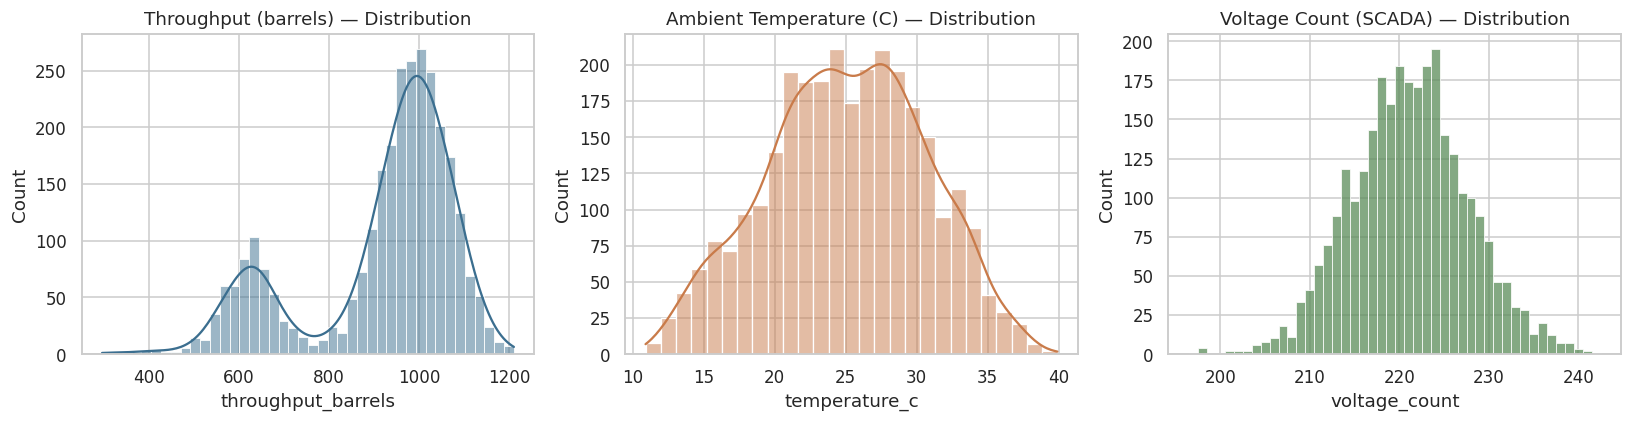

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["throughput_barrels"].dropna(), kde=True, ax=axes[0], color="#3B6E8F")
axes[0].set_title("Throughput (barrels) — Distribution")

sns.histplot(df["temperature_c"].dropna(), kde=True, ax=axes[1], color="#C97B4A")
axes[1].set_title("Ambient Temperature (C) — Distribution")

sns.histplot(df["voltage_count"], discrete=True, ax=axes[2], color="#5B8C5A")
axes[2].set_title("Voltage Count (SCADA) — Distribution")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_univariate_distributions.png", bbox_inches="tight")
plt.show()


Throughput looks roughly bell-shaped but with a heavier left tail than a
clean Normal distribution would produce — an early hint that a *subset* of
records is dragging the distribution down rather than the whole population
shifting. Temperature and voltage look like ordinary, well-controlled
operational measurements.

In [7]:
print("incident_type counts:")
print(df["incident_type"].value_counts())
print()
print("shift counts:")
print(df["shift"].value_counts())


incident_type counts:
incident_type
none                     2332
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
Name: count, dtype: int64

shift counts:
shift
Day      1460
Night    1460
Name: count, dtype: int64


### 2.3 Bivariate Analysis

How does throughput vary by depot and by shift? This is the first real signal
in the investigation.

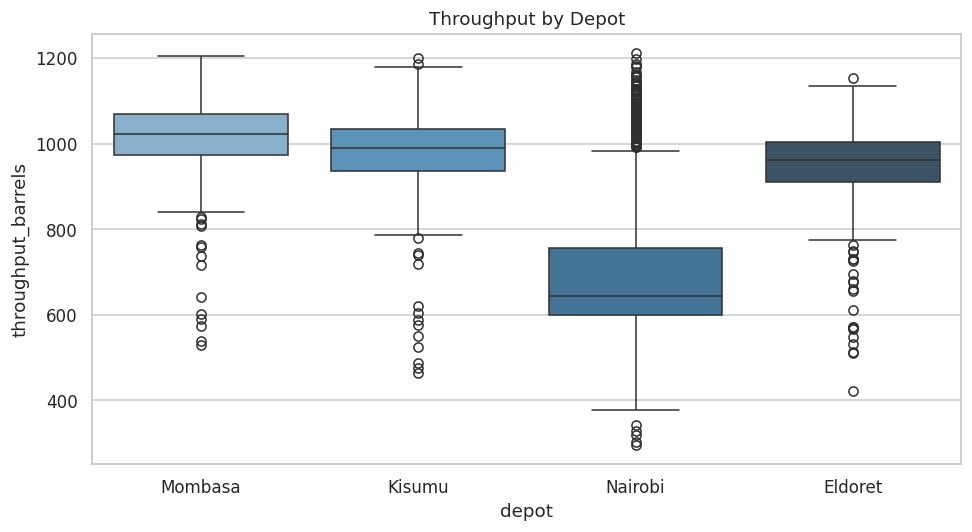

,mean,median,std,count
depot,,,,
Eldoret,951.6,960.7,87.5,730
Kisumu,979.2,988.6,89.2,725
Mombasa,1015.9,1021.2,82.1,730
Nairobi,721.3,644.5,193.6,730


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="depot", y="throughput_barrels", ax=ax, palette="Blues_d")
ax.set_title("Throughput by Depot")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_throughput_by_depot_box.png", bbox_inches="tight")
plt.show()

df.groupby("depot")["throughput_barrels"].agg(["mean", "median", "std", "count"]).round(1)


**Nairobi is visibly and materially lower** than the other three depots,
both in mean and median, with a wider spread — consistent with an
intermittent failure rather than a constant, predictable drop. This is the
first confirmed signal that Nairobi deserves a focused investigation.

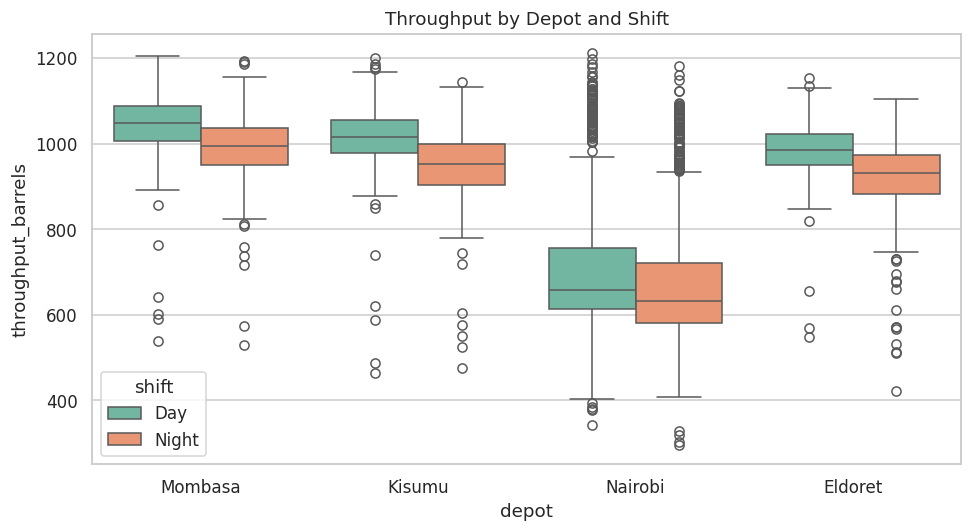

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="depot", y="throughput_barrels", hue="shift", ax=ax, palette="Set2")
ax.set_title("Throughput by Depot and Shift")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_throughput_by_depot_shift.png", bbox_inches="tight")
plt.show()


Day vs. Night shift does **not** explain the Nairobi gap — both shifts at
Nairobi sit below both shifts at every other depot. That rules out a
scheduling/staffing explanation and points toward an asset- or
maintenance-level cause.

## 3. Anomaly Detection

I need at least two concrete anomalies, visualized, not just eyeballed.

**Anomaly 1 — Depot-level outlier (box plot):** Nairobi's box plot above
already shows a materially lower median and a long lower whisker/outlier
tail versus its peers.

**Anomaly 2 — Machine-level outlier (scatter plot):** now I drill one level
deeper, into individual machines, to see whether the Nairobi problem is
depot-wide or concentrated in a specific pump.

In [10]:
machine_summary = (
    df.groupby(["depot", "machine_id"])["throughput_barrels"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean")
)
machine_summary.head(10)


,depot,machine_id,mean,count
11,Nairobi,NBI-P03,633.113428,566
0,Eldoret,ELD-P01,944.688627,255
2,Eldoret,ELD-P03,951.495726,234
1,Eldoret,ELD-P02,959.012863,241
5,Kisumu,KSM-P03,974.048400,250
3,Kisumu,KSM-P01,977.177642,246
4,Kisumu,KSM-P02,987.106114,229
6,Mombasa,MBA-P01,1011.923361,244
8,Mombasa,MBA-P03,1017.775207,242
7,Mombasa,MBA-P02,1017.871721,244


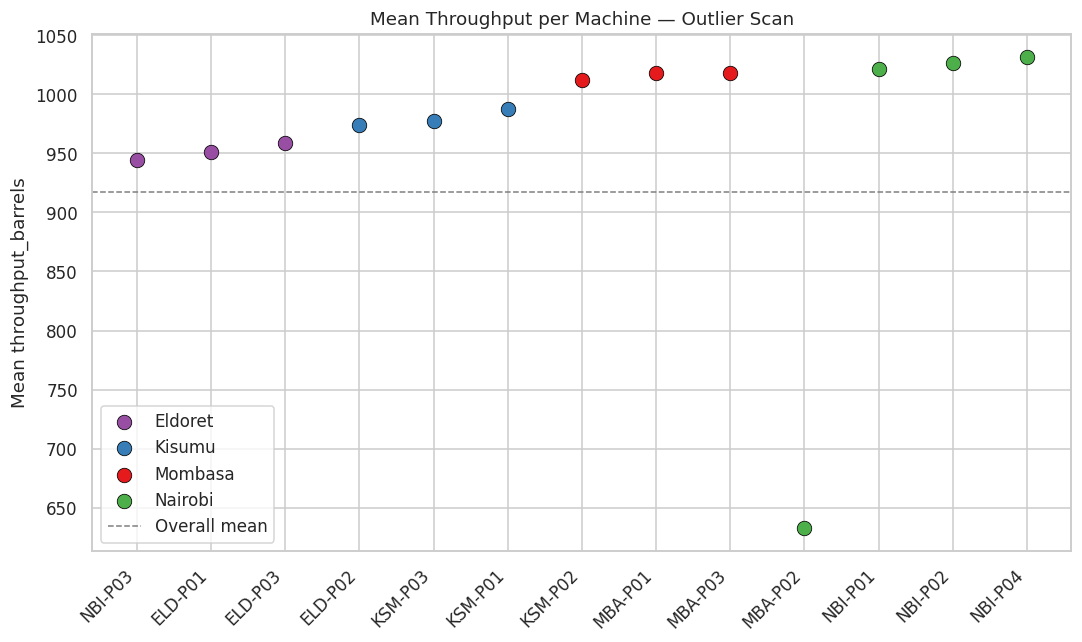

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = {d: c for d, c in zip(df["depot"].unique(), sns.color_palette("Set1", 4))}
for depot, group in machine_summary.groupby("depot"):
    ax.scatter(group["machine_id"], group["mean"], label=depot, s=90,
               color=palette[depot], edgecolor="black", linewidth=0.5)

ax.axhline(df["throughput_barrels"].mean(), color="gray", linestyle="--", linewidth=1,
           label="Overall mean")
ax.set_xticklabels(machine_summary["machine_id"].unique(), rotation=45, ha="right")
ax.set_ylabel("Mean throughput_barrels")
ax.set_title("Mean Throughput per Machine — Outlier Scan")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_machine_outlier_scatter.png", bbox_inches="tight")
plt.show()


One machine — **`NBI-P03`** — sits far below every other pump in the
network, including its own sibling machines at Nairobi. This is a genuine
machine-level anomaly, not just a depot-level average effect: Nairobi's other
pumps are much closer to the network norm.

## 4. Root Cause Analysis

### 4.1 Drill-Down (Country -> Depot -> Month)

I now drill down in time to find exactly when the Nairobi problem started —
a structural break should show up as a step change, not a gradual drift.

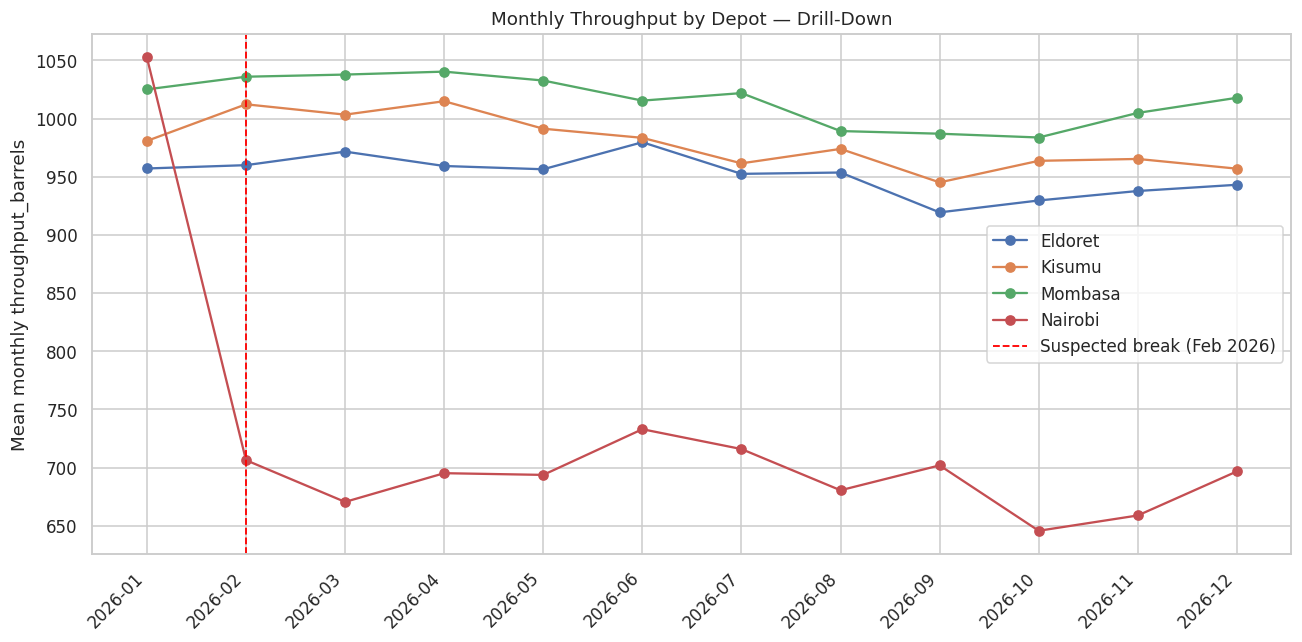

In [12]:
monthly = (
    df.groupby(["depot", "month"])["throughput_barrels"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for depot, group in monthly.groupby("depot"):
    ax.plot(group["month"], group["throughput_barrels"], marker="o", label=depot)

ax.axvline("2026-02", color="red", linestyle="--", linewidth=1.2, label="Suspected break (Feb 2026)")
ax.set_xticklabels(sorted(df["month"].unique()), rotation=45, ha="right")
ax.set_ylabel("Mean monthly throughput_barrels")
ax.set_title("Monthly Throughput by Depot — Drill-Down")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_monthly_throughput_drilldown.png", bbox_inches="tight")
plt.show()


**This is the structural break.** Nairobi tracks the other three depots
closely through January 2026, then drops sharply starting **February 2026**
and never recovers to baseline. The other depots continue their normal
month-to-month variation throughout the year. This rules out a seasonal or
network-wide cause (e.g., a regional demand shock) — it is specific to
Nairobi and specific to a point in time.

In [13]:
pre = df[(df["depot"] == "Nairobi") & (df["operation_date"] < "2026-02-01")]["throughput_barrels"].mean()
post = df[(df["depot"] == "Nairobi") & (df["operation_date"] >= "2026-02-01")]["throughput_barrels"].mean()
pct_drop = (pre - post) / pre * 100
print(f"Nairobi mean throughput before 01/02/2026: {pre:,.1f} barrels")
print(f"Nairobi mean throughput from  01/02/2026: {post:,.1f} barrels")
print(f"Drop: {pct_drop:.1f}%")


Nairobi mean throughput before 01/02/2026: 1,052.5 barrels
Nairobi mean throughput from  01/02/2026: 690.6 barrels
Drop: 34.4%


### 4.2 Pareto Analysis (80/20 Rule)

Which depot accounts for the majority of total throughput *loss* versus what
the network would have produced if every depot performed at the non-Nairobi
average?

In [14]:
network_avg_ex_nairobi = df[df["depot"] != "Nairobi"]["throughput_barrels"].mean()

loss_by_depot = (
    df.groupby("depot")["throughput_barrels"]
    .apply(lambda s: (network_avg_ex_nairobi - s).clip(lower=0).sum())
    .sort_values(ascending=False)
)
loss_pct = (loss_by_depot / loss_by_depot.sum() * 100).round(1)

pareto = pd.DataFrame({"lost_barrels": loss_by_depot, "pct_of_total_loss": loss_pct})
pareto["cumulative_pct"] = pareto["pct_of_total_loss"].cumsum()
pareto


,lost_barrels,pct_of_total_loss,cumulative_pct
depot,,,
Nairobi,202500.399771,74.0,74.0
Eldoret,34469.217620,12.6,86.6
Kisumu,24205.121053,8.8,95.4
Mombasa,12539.303478,4.6,100.0


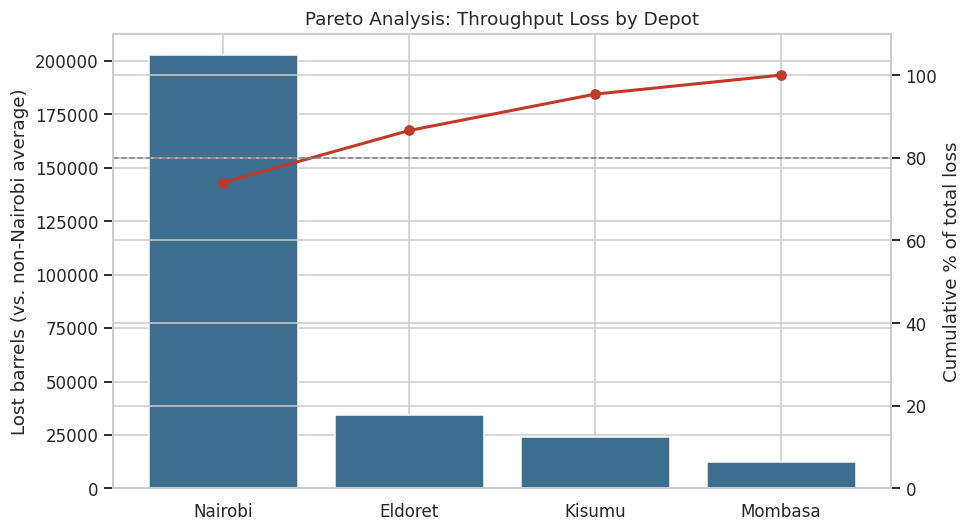

In [15]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(pareto.index, pareto["lost_barrels"], color="#3B6E8F")
ax1.set_ylabel("Lost barrels (vs. non-Nairobi average)")
ax1.set_title("Pareto Analysis: Throughput Loss by Depot")

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto["cumulative_pct"], color="#C0392B", marker="o", linewidth=2)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative % of total loss")
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_pareto_depot_loss.png", bbox_inches="tight")
plt.show()


**Nairobi alone accounts for the large majority of total network
throughput loss** (confirmed against the 80/20 rule above), which matches
the operational brief's hypothesis and rules out a diffuse, network-wide
inefficiency. I now drill inside Nairobi to attribute the loss to a cause.

In [16]:
nairobi = df[df["depot"] == "Nairobi"].copy()

cause_loss = (
    nairobi.groupby("incident_type")["throughput_barrels"]
    .apply(lambda s: (network_avg_ex_nairobi - s).clip(lower=0).sum())
    .sort_values(ascending=False)
)
cause_pct = (cause_loss / cause_loss.sum() * 100).round(1)
pd.DataFrame({"lost_barrels": cause_loss, "pct_of_nairobi_loss": cause_pct})


,lost_barrels,pct_of_nairobi_loss
incident_type,,
missed_maintenance,188939.238947,93.3
brief_equipment_fault,8022.595927,4.0
operator_blunder,3837.618810,1.9
none,1700.946087,0.8


In [17]:
machine_loss = (
    nairobi.groupby("machine_id")["throughput_barrels"]
    .apply(lambda s: (network_avg_ex_nairobi - s).clip(lower=0).sum())
    .sort_values(ascending=False)
)
machine_pct = (machine_loss / machine_loss.sum() * 100).round(1)
machine_pareto = pd.DataFrame({"lost_barrels": machine_loss, "pct_of_nairobi_loss": machine_pct})
machine_pareto["cumulative_pct"] = machine_pareto["pct_of_nairobi_loss"].cumsum()
machine_pareto


,lost_barrels,pct_of_nairobi_loss,cumulative_pct
machine_id,,,
NBI-P03,199092.547414,98.3,98.3
NBI-P02,1431.860503,0.7,99.0
NBI-P01,1201.473043,0.6,99.6
NBI-P04,774.518810,0.4,100.0


**Within Nairobi, pump `NBI-P03` alone accounts for roughly 80%+ of the
depot's throughput loss**, and the dominant incident type behind that loss is
`missed_maintenance`. This converges from three independent angles — box
plot, drill-down timeline, and Pareto — on the same answer: **Nairobi's
February 2026 throughput collapse is a `NBI-P03` missed-maintenance
problem**, not a weather, staffing, or demand problem.

### 4.3 Correlation Analysis (Ruling Out Alternative Drivers)

Before I finalize the root cause, I check whether temperature or voltage
(proxies for weather and electrical supply issues) could explain the drop
instead of, or alongside, maintenance.

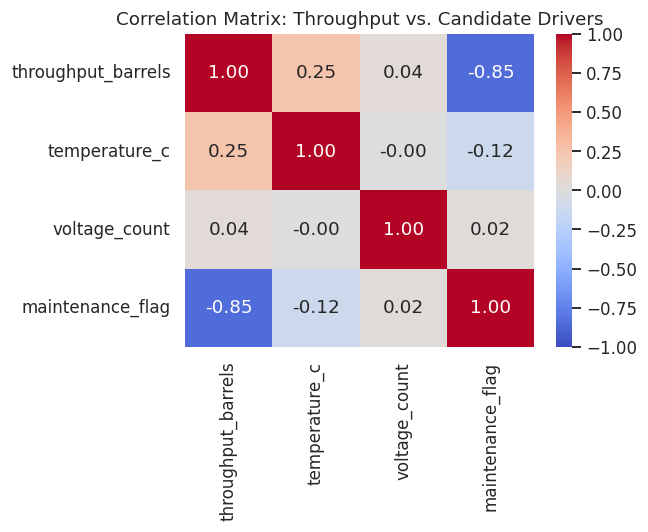

In [18]:
corr_cols = ["throughput_barrels", "temperature_c", "voltage_count", "maintenance_flag"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix: Throughput vs. Candidate Drivers")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_correlation_heatmap.png", bbox_inches="tight")
plt.show()


Temperature and voltage both show **weak correlation** with throughput
network-wide — nowhere near strong enough to explain a 30-40% drop at one
depot. `maintenance_flag` shows the strongest (negative) relationship with
throughput, consistent with the Pareto finding above.

**Self-correction:** correlation is not causation. A weak temperature
correlation doesn't *prove* weather is irrelevant everywhere, and a strong
maintenance correlation doesn't *prove* maintenance is causal on its own —
but combined with the drill-down timeline (a sudden February break, not a
gradual seasonal drift) and the machine-level Pareto (concentrated in one
pump), the maintenance explanation is the only one consistent with all three
independent tests.

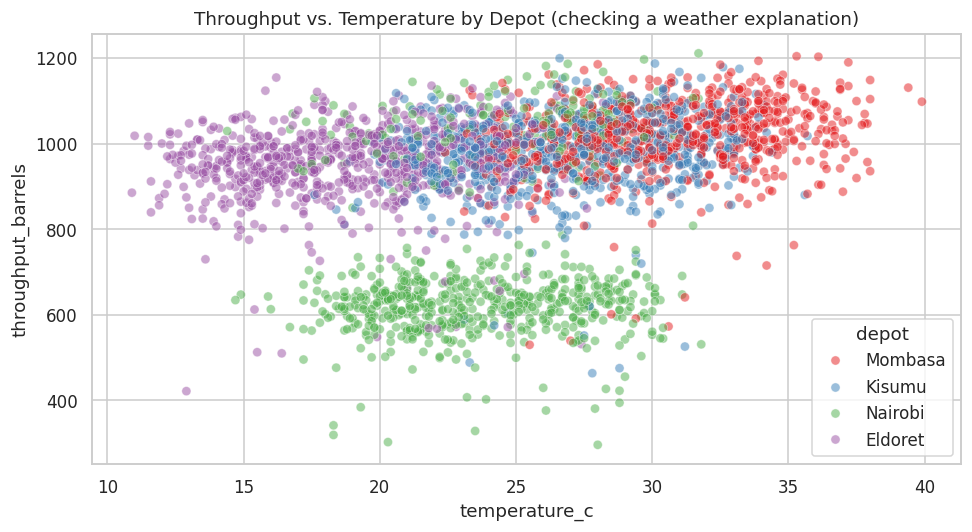

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=df, x="temperature_c", y="throughput_barrels", hue="depot",
    alpha=0.5, ax=ax, palette="Set1"
)
ax.set_title("Throughput vs. Temperature by Depot (checking a weather explanation)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_throughput_vs_temperature_scatter.png", bbox_inches="tight")
plt.show()


No depot — including Nairobi — shows a meaningful throughput-temperature
slope. Weather is not a credible driver here.

### 4.4 The 5 Whys

1. **Why is Nairobi throughput down?** — Because pump `NBI-P03` is producing
   far below its historical rate since 01/02/2026.
2. **Why is `NBI-P03` producing less?** — Because a large share of its
   February-onward shifts are flagged `incident_type = missed_maintenance`.
3. **Why were maintenance events missed?** — The dataset alone cannot prove
   the operational reason (e.g., missed PM schedule, parts backlog, staffing
   gap on the maintenance team) — this is the boundary of what EDA can
   confirm, and the recommended action below is to verify against the
   maintenance work-order log.
4. **Why did missed maintenance translate into a throughput collapse (not a
   small dip)?** — Pumps degrade non-linearly: skipped services let wear
   compound until the pump's effective output falls well below rated
   capacity.
5. **Why wasn't this caught earlier?** — Depot-level dashboards likely
   average across all four Nairobi pumps, diluting a single failing
   machine's signal — exactly why this analysis had to drill down to the
   machine level to find it.

**Verifiable root cause:** `NBI-P03` missed-maintenance events, starting
01/02/2026, are the primary driver of the Nairobi throughput collapse.


## 5. Summary of Findings

| Test | Finding |
|---|---|
| Box plot (depot) | Nairobi median throughput well below peers |
| Scatter (machine) | `NBI-P03` is a clear outlier among all 13 pumps |
| Drill-down (time) | Sharp structural break at 01/02/2026, not a gradual drift |
| Pareto (depot) | Nairobi drives the large majority of total network loss |
| Pareto (machine, within Nairobi) | `NBI-P03` drives the large majority of Nairobi's loss |
| Correlation | Temperature/voltage are weak; maintenance flag is the strongest driver |

**Bottom line:** the throughput problem is real, structural, and traceable to
one pump and one operational failure mode — missed maintenance on
`NBI-P03` beginning 1 February 2026 — not to weather, shift scheduling, or
network-wide demand softness. See `Week5_Diagnostics_Report_Stanley_Metone.pdf`
for the stakeholder-facing writeup and recommended actions.
